# Studi Kasus 3: Tingkat Digitalisasi & Jangkauan Pemasaran

Notebook ini membedah adopsi teknologi UMKM (Media Elektronik), komoditas ekspor, dan jangkauan pasar.

**Metode**: K-Means Clustering + Cuckoo Search Algorithm Optimization


In [1]:
import sys
import os
import pandas as pd
import numpy as np

sys.path.append(os.path.abspath("../src"))
from preprocessing import preprocess_digitalisasi
from csa_core import hitung_optimal_k_elbow, cuckoo_search_kmeans, final_kmeans, plot_hasil_cluster, evaluasi_kualitas_klasterisasi

# 1. Preprocessing Data Khusus Skenario
df_raw, df_scaled, list_fitur = preprocess_digitalisasi("data/Data Set UMKM.xlsx")
X_scaled = df_scaled.values

print(f"Data shape: {X_scaled.shape}")
print(f"Fitur: {list_fitur}")
df_raw.head()


Data shape: (2769, 4)
Fitur: ['Skor Digitalisasi', 'Ekspor', 'Jangkauan Pasar', 'Tingkat Omset']


,Skor Digitalisasi,Ekspor,Jangkauan Pasar,Tingkat Omset
0,0,0,1,1
1,2,1,2,1
2,3,1,1,1
3,2,1,3,1
4,1,1,2,1



Mencari jumlah klaster (K) optimal...


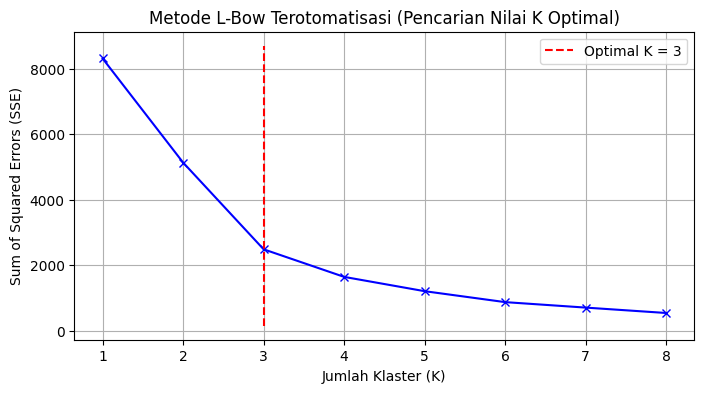

In [2]:
# 2. Mencari K-Optimal secara Otomatis
print("\nMencari jumlah klaster (K) optimal...")
optimal_k = hitung_optimal_k_elbow(X_scaled, max_k=8)


In [3]:
# 3. Proses Training (Fitting) dengan Cuckoo Search Algorithm
print(f"\nMemulai Cuckoo Search dengan K={optimal_k}...")
best_nest, fitness_history = cuckoo_search_kmeans(
    X=X_scaled, 
    k=optimal_k, 
    n_nests=10, 
    max_iter=30, 
    pa=0.25
)

# 4. Fine-Tuning dengan K-Means konvensional
print("\nMelakukan Fine-Tuning K-Means...")
labels, final_centroids = final_kmeans(X_scaled, best_nest)



Memulai Cuckoo Search dengan K=3...

Melakukan Fine-Tuning K-Means...


      HASIL UJI METRIK KUALITAS KLASTERISASI
1. Silhouette Score          : 0.5380
   [Interpretasi]: BUKTINYA BAIK. Terdapat struktur klaster yang masuk akal.

2. Davies-Bouldin Index (DBI): 0.6534
   [Interpretasi]: SANGAT BAGUS. Klaster terpisah jauh dengan kepadatan terpusat.

3. Calinski-Harabasz Index   : 3237.0041
   [Interpretasi]: Semakin tinggi angka ini, semakin rapat/padat (dense) klaster Anda.

4. SSE (Sum Squared Error)   : 2486.7036
   [Interpretasi]: Mengukur kuadrat jarak deviasi. Turunnya SSE di tiap iterasi membuktikan kinerja baik.

5. MAE (Mean Absolute Error) : 1.0654
   [Interpretasi]: Rata-rata 'jarak lurus' data meleset dari pusat klaster mereka.

Distribusi Klaster:
Cluster
2    1683
0     937
1     149
Name: count, dtype: int64
-> Dimensi 4D terdeteksi! Mengecilkan ke Ruang Visual 3D dengan Principal Component Analysis (PCA).


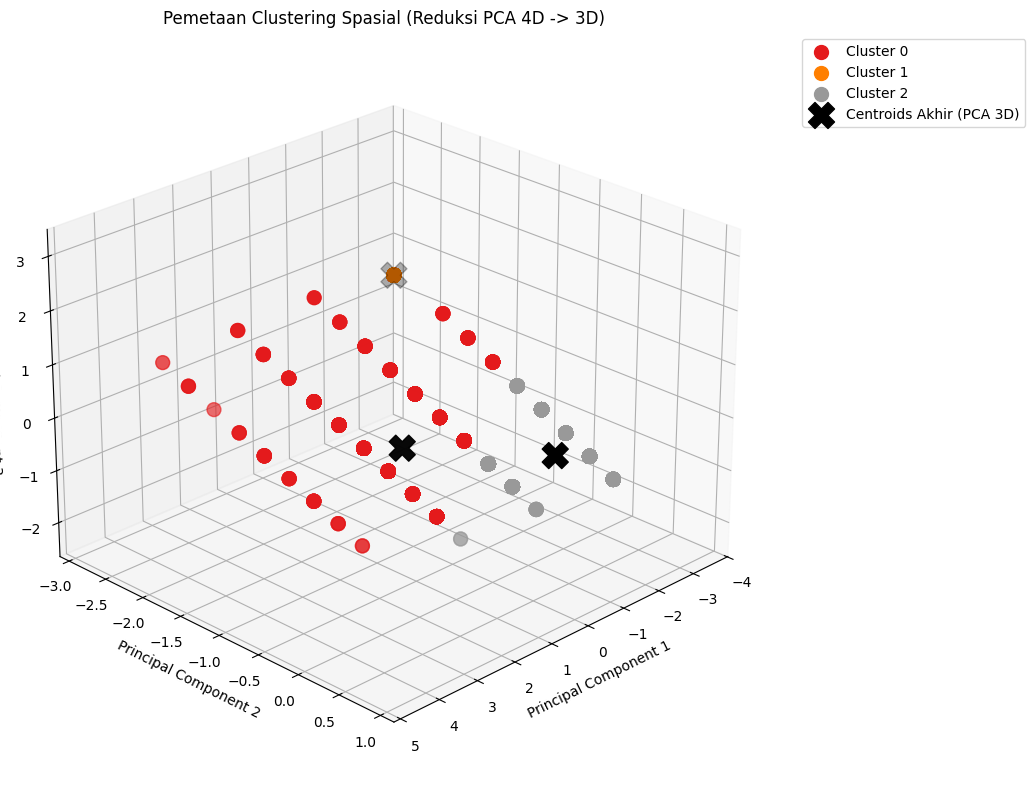

In [4]:
# 5. Evaluasi Metrik & Visualisasi
evaluasi_kualitas_klasterisasi(X_scaled, labels, final_centroids)

# Memasukkan hasil klaster ke dataframe asli
df_raw["Cluster"] = labels
print("\nDistribusi Klaster:")
print(df_raw["Cluster"].value_counts())

# Plot hasil
plot_hasil_cluster(X_scaled, final_centroids, labels, list_fitur)
